# AML Transaction Analysis → Credit-Dataset Transaction Generator

This notebook consolidates everything from our conversation into one pipeline:

1. **Memory-efficient AML analysis** — stream `LI-Medium_Trans.csv` in chunks (instead of loading
   31M rows at once), with dtypes downcast and dict-based lookups instead of merges.
2. **US-banks-only filter** — restrict both the accounts table and the streamed transactions to
   US banks (non-US banks are named `"<Country> Bank #<id>"`, e.g. `"China Bank #10"`).
3. **Correlation & distribution analysis** — Amount Paid/Received/Is Laundering correlations,
   transactions-per-account distribution, accounts/banks-per-entity vs. transaction volume.
4. **Average-transactions-per-account-count relationship** — fit *per entity type*
   (`Individual` vs `Sole Proprietorship`), since that's what step 5 needs.
5. **Transaction generator for the credit-score dataset** — for each customer in
   `train.csv`, use their `Num_Bank_Accounts` and `Occupation` to simulate a realistic number of
   transactions (and the transactions themselves), borrowing the account→transaction relationship
   learned from the AML data. `Occupation` unknown or `Entrepreneur` → modeled as a
   `Sole Proprietorship`; everything else → modeled as an `Individual`.

Adjust `CHUNKSIZE` in Part 1 if you still hit RAM limits, and adjust `train_data_path` in Part 2
to wherever your credit-score `train.csv` lives.


# Part 1 — AML dataset: memory-efficient loading & analysis

In [77]:
import gc
import pickle
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def ram_gb():
    return psutil.virtual_memory().available / 1e9

print(f"RAM available: {ram_gb():.2f} GB")

RAM available: 1.41 GB


## 1.1 Download data

In [78]:
import kagglehub

path = kagglehub.dataset_download(
    "ealtman2019/ibm-transactions-for-anti-money-laundering-aml",
    path="LI-Small_Trans.csv",
    output_dir=r"../data/aml"
)
path1 = kagglehub.dataset_download(
    "ealtman2019/ibm-transactions-for-anti-money-laundering-aml",
    path="LI-Small_accounts.csv",
    output_dir=r"../data/aml"
)
print(path)
print(path1)

100%|███████████████████████████████████████████████████████████████████████████████| 620M/620M [09:08<00:00, 1.18MB/s]


100%|█████████████████████████████████████████████████████████████████████████████| 45.1M/45.1M [00:33<00:00, 1.41MB/s]

../data/aml\LI-Small_Trans.csv
../data/aml\LI-Small_accounts.csv


## 1.2 Load `accounts.csv` and keep US banks only

`accounts.csv` is small (~2M rows) so it's safe to load in full. Non-US banks follow the pattern
`"<Country> Bank #<number>"` (e.g. `"China Bank #10"`) — US banks don't have that country prefix,
so we filter on that.

In [2]:
accounts = pd.read_csv(
    "../data/aml/LI-Large_accounts.csv",
    dtype={
        "Bank Name": "category",
        "Bank ID": "int32",
        "Account Number": "string",
        "Entity ID": "category",
        "Entity Name": "string",
    },
)

# Entity "type" is embedded in Entity Name, e.g. "Corporation #41344"
accounts["Entity Type"] = accounts["Entity Name"].str.extract(r"^([A-Za-z ]+) #").astype("category")

# ---- US-banks-only filter ----
foreign_pattern = r"^[A-Za-z ]+ Bank #\d+$"
accounts["Is_Foreign_Bank"] = accounts["Bank Name"].str.match(foreign_pattern)

us_bank_ids = set(accounts.loc[~accounts["Is_Foreign_Bank"], "Bank ID"].unique())
print("US banks:", len(us_bank_ids), "/ Total banks:", accounts["Bank ID"].nunique())

accounts_us = accounts[accounts["Bank ID"].isin(us_bank_ids)].copy()

print("Unique US accounts:", accounts_us["Account Number"].nunique())
print("Unique US entities:", accounts_us["Entity ID"].nunique())
print("\nEntity type distribution (US banks only):")
print(accounts_us["Entity Type"].value_counts())

US banks: 43450 / Total banks: 119619
Unique US accounts: 790450
Unique US entities: 287250

Entity type distribution (US banks only):
Entity Type
Partnership            293678
Sole Proprietorship    269695
Corporation            231207
Individual               1685
Direct                    333
Country                    16
Name: count, dtype: int64


In [43]:
accounts_m = pd.read_csv(
    "../data/aml/LI-Medium_accounts.csv",
    dtype={
        "Bank Name": "category",
        "Bank ID": "int32",
        "Account Number": "string",
        "Entity ID": "category",
        "Entity Name": "string",
    },
)

# Entity "type" is embedded in Entity Name, e.g. "Corporation #41344"
accounts_m["Entity Type"] = accounts_m["Entity Name"].str.extract(r"^([A-Za-z ]+) #").astype("category")

# ---- US-banks-only filter ----
foreign_pattern = r"^[A-Za-z ]+ Bank #\d+$"
accounts_m["Is_Foreign_Bank"] = accounts_m["Bank Name"].str.match(foreign_pattern)

us_bank_ids_m = set(accounts_m.loc[~accounts_m["Is_Foreign_Bank"], "Bank ID"].unique())
print("US banks:", len(us_bank_ids_m), "/ Total banks:", accounts_m["Bank ID"].nunique())

accounts_us_m = accounts_m[accounts_m["Bank ID"].isin(us_bank_ids_m)].copy()

print("Unique US accounts:", accounts_us_m["Account Number"].nunique())
print("Unique US entities:", accounts_us_m["Entity ID"].nunique())
print("\nEntity type distribution (US banks only):")
print(accounts_us_m["Entity Type"].value_counts())

US banks: 43449 / Total banks: 119617
Unique US accounts: 781632
Unique US entities: 286280

Entity type distribution (US banks only):
Entity Type
Partnership            287610
Sole Proprietorship    265752
Corporation            226361
Individual               1667
Direct                    230
Country                    18
Name: count, dtype: int64


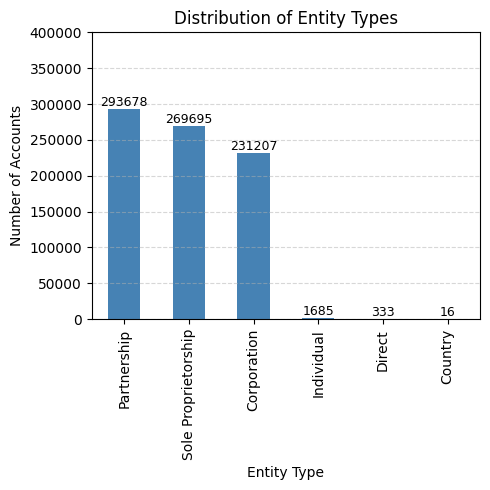

In [3]:
import matplotlib.pyplot as plt

entity_counts = accounts_us["Entity Type"].value_counts()

ax = entity_counts.plot(kind="bar", figsize=(5, 5), color="steelblue")

for container in ax.containers:
    ax.bar_label(container, fontsize=9)

ax.set_title("Distribution of Entity Types")
ax.set_xlabel("Entity Type")
ax.set_ylabel("Number of Accounts")

plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.ylim(top=400000)

plt.tight_layout()
plt.show()

Accounts per entity — summary stats:
count    287250.000000
mean          2.773243
std           5.177014
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         323.000000
Name: Account Number, dtype: float64


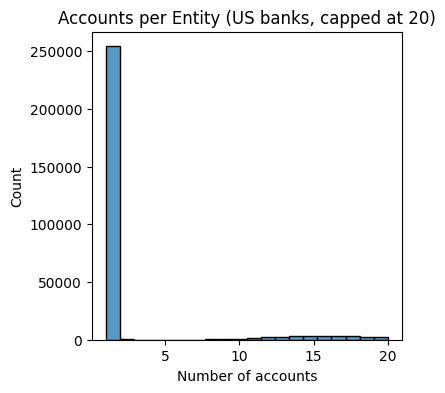


Accounts per bank — summary stats:
count    43450.000000
mean        18.334039
std         81.335700
min          1.000000
25%          2.000000
50%          4.000000
75%          7.000000
max       3424.000000
Name: Account Number, dtype: float64

Entities operating across multiple (US) banks: 32972 out of 287250


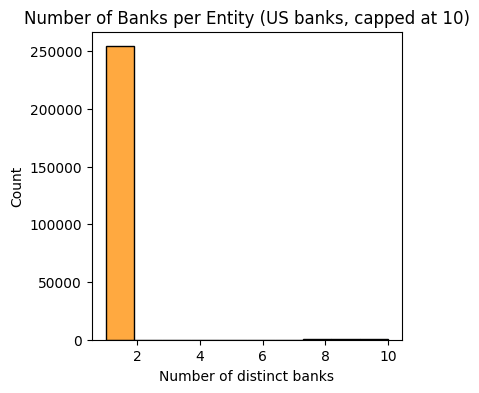

In [4]:
# ---- How many bank accounts does an entity have? ----
accts_per_entity = accounts_us.groupby("Entity ID", observed=True)["Account Number"].count()
print("Accounts per entity — summary stats:")
print(accts_per_entity.describe())

fig, ax = plt.subplots(figsize=(4, 4))
sns.histplot(accts_per_entity[accts_per_entity <= 20], bins=20, ax=ax)
ax.set_title("Accounts per Entity (US banks, capped at 20)")
ax.set_xlabel("Number of accounts")
plt.show()

# ---- Accounts per bank ----
accts_per_bank = accounts_us.groupby("Bank ID", observed=True)["Account Number"].count()
print("\nAccounts per bank — summary stats:")
print(accts_per_bank.describe())

# ---- How many banks does an entity span? ----
banks_per_entity = accounts_us.groupby("Entity ID", observed=True)["Bank ID"].nunique()
print("\nEntities operating across multiple (US) banks:",
      (banks_per_entity > 1).sum(), "out of", len(banks_per_entity))

fig, ax = plt.subplots(figsize=(4, 4))
sns.histplot(banks_per_entity[banks_per_entity <= 10], bins=10, ax=ax, color="darkorange")
ax.set_title("Number of Banks per Entity (US banks, capped at 10)")
ax.set_xlabel("Number of distinct banks")
plt.show()

In [5]:
# ---- Lightweight lookup dicts (used instead of merging the huge transactions table) ----
acct2entity = dict(zip(accounts_us["Account Number"], accounts_us["Entity ID"]))
acct2etype  = dict(zip(accounts_us["Account Number"], accounts_us["Entity Type"]))

print(f"RAM available after building lookup dicts: {ram_gb():.2f} GB")

RAM available after building lookup dicts: 0.62 GB


## 1.3 Stream through `Trans.csv` in chunks (US-to-US transactions only)

Same single-pass accumulation approach as before, with an added filter so only transactions
where **both** the sending and receiving bank are US banks are counted. Switch `&` to `|` below
if you want transactions touching a US bank on *either* side instead of strictly domestic ones.

In [6]:
CHUNKSIZE = 2_000_000  # lower this (e.g. 500_000) if you still run out of RAM

usecols = ["Timestamp", "From Bank", "Account", "To Bank", "Account.1",
           "Amount Received", "Receiving Currency", "Amount Paid",
           "Payment Currency", "Payment Format", "Is Laundering"]

dtype_map = {
    "From Bank": "int32",
    "To Bank": "int32",
    "Amount Received": "float32",
    "Amount Paid": "float32",
    "Receiving Currency": "category",
    "Payment Currency": "category",
    "Payment Format": "category",
    "Is Laundering": "int8",
}

# ---------- accumulators  ----------
out_degree = Counter()
in_degree = Counter()
bank_out_count = Counter()
bank_in_count = Counter()
entity_txn_count = Counter()
entity_type_count = Counter()
entity_type_launder_sum = Counter()

currency_pay_counts = Counter()
currency_recv_counts = Counter()
format_counts = Counter()
format_launder_sum = Counter()

daily_counts = Counter()
hourly_counts = Counter()
hourly_launder_sum = Counter()

same_bank_launder = Counter()
cross_currency_launder = Counter()
same_entity_launder = Counter()

n_rows = 0
s_paid = s_recv = s_laund = 0.0
sq_paid = sq_recv = sq_laund = 0.0
xy_paid_recv = xy_paid_laund = xy_recv_laund = 0.0

duplicate_rows = 0
ts_min, ts_max = None, None

reader = pd.read_csv("../data/aml/LI-Large_Trans.csv", usecols=usecols, dtype=dtype_map, chunksize=CHUNKSIZE)

for i, chunk in enumerate(reader):
    # ---- US-banks-only filter ----
    chunk = chunk[chunk["From Bank"].isin(us_bank_ids) & chunk["To Bank"].isin(us_bank_ids)]
    n = len(chunk)
    if n == 0:
        continue
    n_rows += n

    duplicate_rows += chunk.duplicated().sum()

    ts = pd.to_datetime(chunk["Timestamp"], format="%Y/%m/%d %H:%M")
    ts_min = ts.min() if ts_min is None else min(ts_min, ts.min())
    ts_max = ts.max() if ts_max is None else max(ts_max, ts.max())
    hours = ts.dt.hour
    dates = ts.dt.date

    hourly_counts.update(hours.value_counts().to_dict())
    daily_counts.update(pd.Series(dates).value_counts().to_dict())
    hourly_launder_sum.update(chunk.groupby(hours, observed=True)["Is Laundering"].sum().to_dict())

    paid = chunk["Amount Paid"].astype("float64")
    recv = chunk["Amount Received"].astype("float64")
    laund = chunk["Is Laundering"].astype("float64")

    s_paid += paid.sum();  sq_paid += (paid ** 2).sum()
    s_recv += recv.sum();  sq_recv += (recv ** 2).sum()
    s_laund += laund.sum(); sq_laund += (laund ** 2).sum()
    xy_paid_recv  += (paid * recv).sum()
    xy_paid_laund += (paid * laund).sum()
    xy_recv_laund += (recv * laund).sum()

    out_degree.update(chunk["Account"].value_counts().to_dict())
    in_degree.update(chunk["Account.1"].value_counts().to_dict())

    bank_out_count.update(chunk["From Bank"].value_counts().to_dict())
    bank_in_count.update(chunk["To Bank"].value_counts().to_dict())

    currency_pay_counts.update(chunk["Payment Currency"].value_counts().to_dict())
    currency_recv_counts.update(chunk["Receiving Currency"].value_counts().to_dict())
    format_counts.update(chunk["Payment Format"].value_counts().to_dict())
    format_launder_sum.update(chunk.groupby(chunk["Payment Format"], observed=True)["Is Laundering"].sum().to_dict())

    same_bank = chunk["From Bank"] == chunk["To Bank"]
    cross_curr = chunk["Payment Currency"].astype(str) != chunk["Receiving Currency"].astype(str)

    same_bank_launder.update(chunk.groupby([same_bank, chunk["Is Laundering"]]).size().to_dict())
    cross_currency_launder.update(chunk.groupby([cross_curr, chunk["Is Laundering"]]).size().to_dict())

    sender_entity = chunk["Account"].map(acct2entity)
    receiver_entity = chunk["Account.1"].map(acct2entity)
    sender_etype = chunk["Account"].map(acct2etype)

    same_entity = sender_entity == receiver_entity
    same_entity_launder.update(chunk.groupby([same_entity, chunk["Is Laundering"]]).size().to_dict())

    entity_type_count.update(sender_etype.value_counts(dropna=True).to_dict())
    entity_type_launder_sum.update(
        chunk.groupby(sender_etype, observed=True)["Is Laundering"].sum().to_dict()
    )

    entity_txn_count.update(sender_entity.dropna().value_counts().to_dict())
    entity_txn_count.update(receiver_entity.dropna().value_counts().to_dict())

    del chunk, ts, hours, dates, paid, recv, laund, same_bank, cross_curr
    del sender_entity, receiver_entity, sender_etype, same_entity
    if i % 3 == 0:
        gc.collect()
        print(f"  processed {n_rows:,} US-to-US rows so far | RAM available: {ram_gb():.2f} GB")

print(f"\nDone. Total US-to-US rows processed: {n_rows:,}")
print("Duplicate rows:", duplicate_rows)
print("Date range:", ts_min, "to", ts_max)

  processed 761,149 US-to-US rows so far | RAM available: 0.63 GB
  processed 3,012,776 US-to-US rows so far | RAM available: 0.79 GB
  processed 5,258,190 US-to-US rows so far | RAM available: 1.10 GB
  processed 7,503,577 US-to-US rows so far | RAM available: 1.05 GB
  processed 9,747,825 US-to-US rows so far | RAM available: 1.21 GB
  processed 11,993,491 US-to-US rows so far | RAM available: 1.20 GB
  processed 14,239,534 US-to-US rows so far | RAM available: 1.24 GB
  processed 16,487,797 US-to-US rows so far | RAM available: 1.22 GB
  processed 18,733,579 US-to-US rows so far | RAM available: 1.28 GB
  processed 21,176,895 US-to-US rows so far | RAM available: 1.23 GB
  processed 23,240,036 US-to-US rows so far | RAM available: 1.24 GB
  processed 25,487,398 US-to-US rows so far | RAM available: 1.31 GB
  processed 27,741,850 US-to-US rows so far | RAM available: 1.33 GB
  processed 29,983,623 US-to-US rows so far | RAM available: 1.24 GB
  processed 32,230,272 US-to-US rows so f

## 1.4 Class balance, amounts, currency & payment-format breakdowns

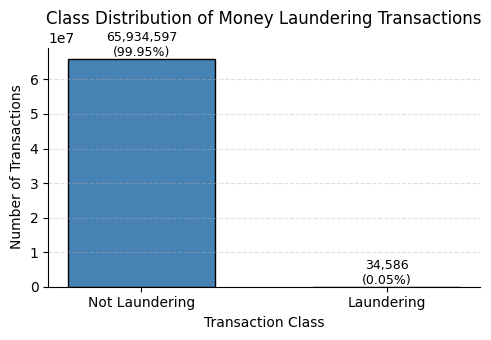

In [7]:
# Create class distribution
is_laundering_count = pd.Series({ 0: n_rows - int(s_laund),1: int(s_laund)})
is_laundering_pct = (is_laundering_count / n_rows) * 100

# Plot
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(
    ["Not Laundering", "Laundering"],
    is_laundering_count.values,
    color=["steelblue", "indianred"],
    edgecolor="black",
    width=0.6
)
for bar, count, pct in zip(
    bars,
    is_laundering_count.values,
    is_laundering_pct.values
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{count:,}\n({pct:.2f}%)",
        ha="center",
        va="bottom",
        fontsize=9
    )
# Formatting
ax.set_title("Class Distribution of Money Laundering Transactions")
ax.set_xlabel("Transaction Class")
ax.set_ylabel("Number of Transactions")

ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Payment Currency distribution:
US Dollar            65773815
Euro                    83151
Bitcoin                 47114
Yuan                    29630
Saudi Riyal             18183
Yen                      9984
Ruble                    4383
Rupee                    2923
Mexican Peso                0
Australian Dollar           0
Canadian Dollar             0
UK Pound                    0
Swiss Franc                 0
Brazil Real                 0
Shekel                      0
dtype: int64

Payment Format distribution:
Cheque          26281901
Credit Card     18938133
ACH              8600867
Cash             6854982
Reinvestment     2858019
Wire             2388167
Bitcoin            47114
dtype: int64


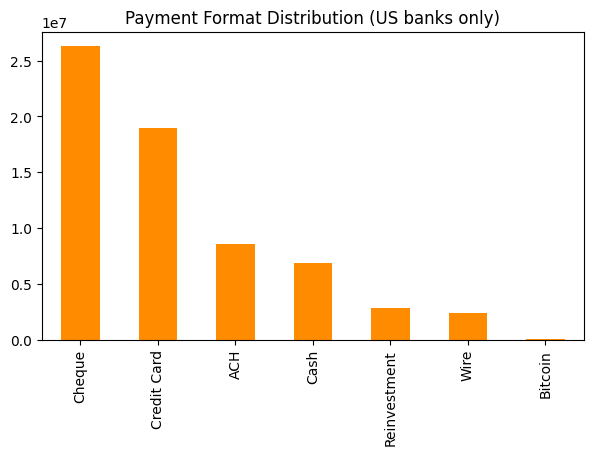


Laundering rate by Payment Format:
ACH             0.002916
Cheque          0.000194
Cash            0.000193
Credit Card     0.000163
Bitcoin         0.000000
Reinvestment    0.000000
Wire            0.000000
dtype: float64


In [8]:
print("Payment Currency distribution:")
print(pd.Series(currency_pay_counts).sort_values(ascending=False))

print("\nPayment Format distribution:")
format_s = pd.Series(format_counts).sort_values(ascending=False)
print(format_s)

fig, ax = plt.subplots(figsize=(7, 4))
format_s.plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("Payment Format Distribution (US banks only)")
plt.show()

fmt_rate = (pd.Series(format_launder_sum) / pd.Series(format_counts)).sort_values(ascending=False)
print("\nLaundering rate by Payment Format:")
print(fmt_rate)

Share of intra-bank transactions: 0.06783944861042163
                  0         1
Same_Bank                    
False      0.999439  0.000561
True       0.999974  0.000026


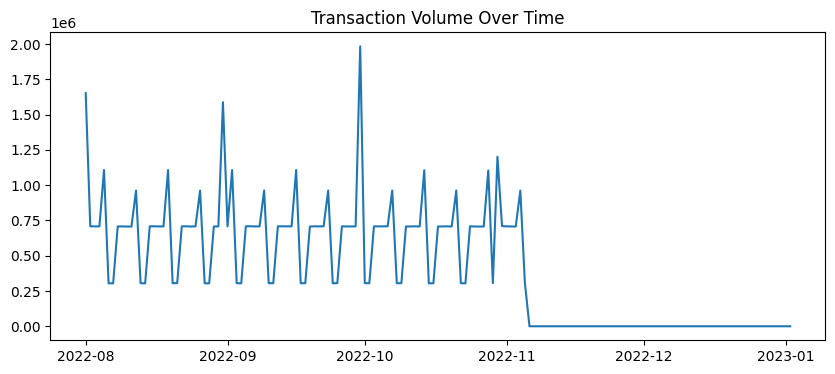

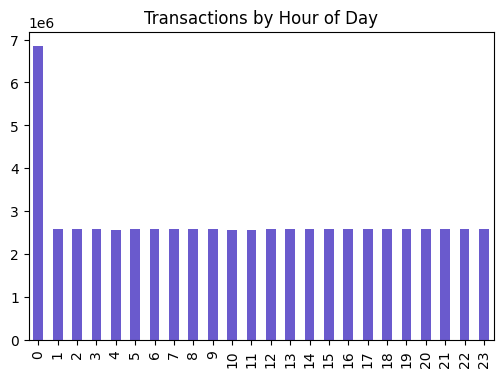

In [9]:
sb = pd.Series(same_bank_launder).unstack(fill_value=0)
sb.index.name = "Same_Bank"
print("Share of intra-bank transactions:",
      sb.loc[True].sum() / (sb.loc[True].sum() + sb.loc[False].sum()))
print((sb.T / sb.sum(axis=1)).T)

daily_s = pd.Series(daily_counts).sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
daily_s.plot(ax=ax)
ax.set_title("Transaction Volume Over Time")
plt.show()

hourly_s = pd.Series(hourly_counts).sort_index()
fig, ax = plt.subplots(figsize=(6, 4))
hourly_s.plot(kind="bar", ax=ax, color="slateblue")
ax.set_title("Transactions by Hour of Day")
plt.show()

## 1.5 Correlation matrix (Amount Paid / Amount Received / Is Laundering)

                 Amount Paid  Amount Received  Is Laundering
Amount Paid         1.000000     2.415438e-01   1.325141e-03
Amount Received     0.241544     1.000000e+00   9.766841e-07
Is Laundering       0.001325     9.766841e-07   1.000000e+00


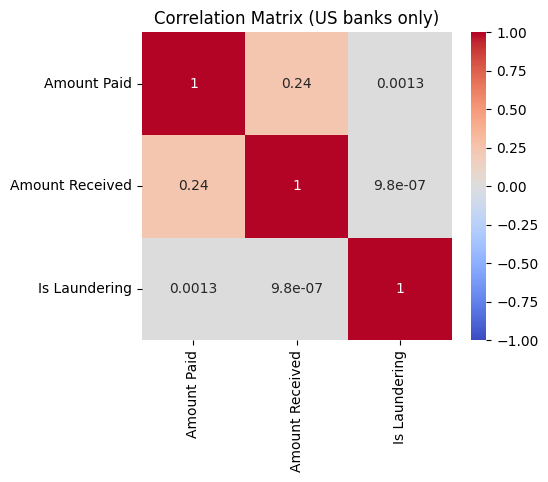


Mean Amount Paid:     337,659.38
Mean Amount Received: 6,184,886.42


In [10]:
def pearson(sx, sqx, sy, sqy, sxy, n):
    cov = n * sxy - sx * sy
    var_x = n * sqx - sx ** 2
    var_y = n * sqy - sy ** 2
    return cov / np.sqrt(var_x * var_y)

r_paid_recv  = pearson(s_paid, sq_paid, s_recv, sq_recv, xy_paid_recv, n_rows)
r_paid_laund = pearson(s_paid, sq_paid, s_laund, sq_laund, xy_paid_laund, n_rows)
r_recv_laund = pearson(s_recv, sq_recv, s_laund, sq_laund, xy_recv_laund, n_rows)

corr_matrix = pd.DataFrame(
    [[1.0, r_paid_recv, r_paid_laund],
     [r_paid_recv, 1.0, r_recv_laund],
     [r_paid_laund, r_recv_laund, 1.0]],
    index=["Amount Paid", "Amount Received", "Is Laundering"],
    columns=["Amount Paid", "Amount Received", "Is Laundering"],
)
print(corr_matrix)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Matrix (US banks only)")
plt.show()

mean_amount = s_paid / n_rows
print(f"\nMean Amount Paid:     {mean_amount:,.2f}")
print(f"Mean Amount Received: {s_recv/n_rows:,.2f}")

## 1.6 Distribution of transactions per bank account (fan-in / fan-out)

Sending activity per account — summary:
count    7.776210e+05
mean     8.483462e+01
std      7.177783e+03
min      1.000000e+00
25%      6.000000e+00
50%      1.200000e+01
75%      2.100000e+01
max      6.327667e+06
Name: out_degree, dtype: float64

Receiving activity per account — summary:
count    645126.000000
mean        102.257827
std         131.751986
min           1.000000
25%           7.000000
50%          25.000000
75%         196.000000
max       31734.000000
Name: in_degree, dtype: float64

Total transactions per account — summary:
count    7.894720e+05
mean     1.671223e+02
std      7.161335e+03
min      1.000000e+00
25%      1.400000e+01
50%      3.200000e+01
75%      2.290000e+02
max      6.359401e+06
dtype: float64


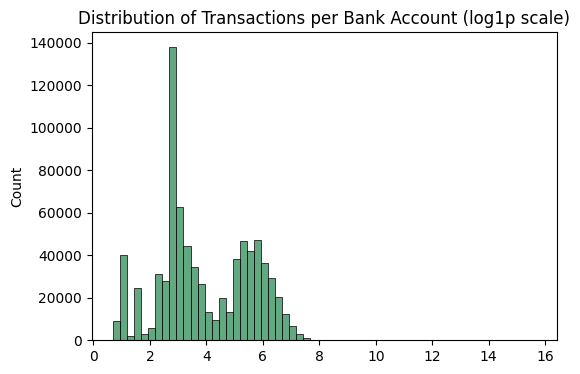

In [11]:
out_degree_s = pd.Series(out_degree, name="out_degree")
in_degree_s = pd.Series(in_degree, name="in_degree")

print("Sending activity per account — summary:")
print(out_degree_s.describe())
print("\nReceiving activity per account — summary:")
print(in_degree_s.describe())

total_degree = out_degree_s.add(in_degree_s, fill_value=0)
print("\nTotal transactions per account — summary:")
print(total_degree.describe())

fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(np.log1p(total_degree), bins=60, ax=ax, color="seagreen")
ax.set_title("Distribution of Transactions per Bank Account (log1p scale)")
plt.show()

## 1.7 Entities: accounts, banks, and transaction volume — correlation & distribution

Per-entity summary (accounts / transactions):
          n_accounts  n_transactions
count  287250.000000    2.872500e+05
mean        2.773243    4.593155e+02
std         5.177014    1.187319e+04
min         1.000000    0.000000e+00
25%         1.000000    1.770000e+02
50%         1.000000    3.210000e+02
75%         1.000000    5.730000e+02
max       323.000000    6.360010e+06

Correlation between # accounts and # transactions per entity:
                n_accounts  n_transactions
n_accounts        1.000000        0.024255
n_transactions    0.024255        1.000000


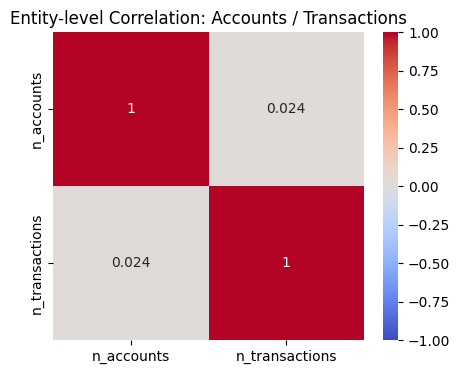

In [12]:
entity_txn_s = pd.Series(entity_txn_count, name="n_transactions")

df_entity = pd.DataFrame({
    "n_accounts": accts_per_entity,
}).join(entity_txn_s, how="left").fillna({"n_transactions": 0})

print("Per-entity summary (accounts / transactions):")
print(df_entity.describe())

print("\nCorrelation between # accounts and # transactions per entity:")
print(df_entity.corr())

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(df_entity.corr(), annot=True, cmap="coolwarm", ax=ax, vmin=-1, vmax=1)
ax.set_title("Entity-level Correlation: Accounts / Transactions")
plt.show()

## 1.8 Average transactions per entity, by number of accounts held

Answers: *"if a person has n bank accounts, on average how many transactions do they do?"*

                   mean  median   count
n_accounts                             
1            357.105538   288.0  254137
2            370.346667    24.0     225
3            950.520000    40.5      50
4            167.235294    56.0      17
5            295.818182   219.0      44
6            379.828125   306.5      64
7            441.384615   343.0     143
8            530.075710   465.0     317
9            573.159091   492.0     572
10           638.463705   573.0     923
11           723.783685   633.0    1373
12           768.637904   686.0    1947
13           838.819162   753.0    2411
14          3047.149561   816.0    2962
15           959.138123   900.5    3048
16          1021.784674   942.0    3158
17          1090.742448  1013.0    3211
18          1145.563063  1068.0    2886
19          1210.204371  1132.0    2471
20          1294.031584  1201.5    2058

On average, each extra bank account adds ~55.63 transactions (baseline ~305.05 txns with 1 account)


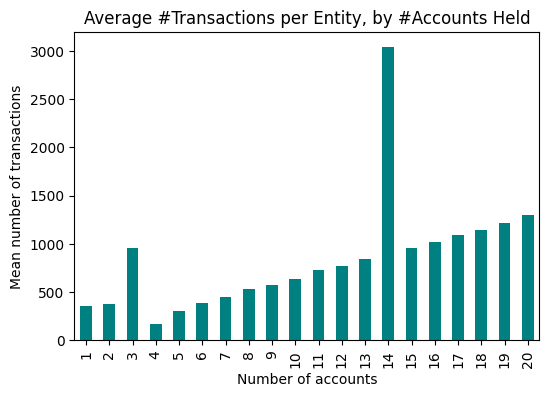

In [13]:
avg_txn_by_naccounts = df_entity.groupby("n_accounts")["n_transactions"].agg(["mean", "median", "count"])
print(avg_txn_by_naccounts.head(20))

slope, intercept = np.polyfit(df_entity["n_accounts"], df_entity["n_transactions"], 1)
print(f"\nOn average, each extra bank account adds ~{slope:.2f} transactions "
      f"(baseline ~{intercept:.2f} txns with 1 account)")

fig, ax = plt.subplots(figsize=(6, 4))
avg_txn_by_naccounts["mean"][avg_txn_by_naccounts["mean"].index <= 20].plot(kind="bar", ax=ax, color="teal")
ax.set_title("Average #Transactions per Entity, by #Accounts Held")
ax.set_xlabel("Number of accounts"); ax.set_ylabel("Mean number of transactions")
plt.show()

## 1.9 Same-entity transfers & laundering rate by entity type

In [14]:
se = pd.Series(same_entity_launder).unstack(fill_value=0)
se.index.name = "Same_Entity_Transfer"
print("Same-entity transfer rate:",
      se.loc[True].sum() / (se.loc[True].sum() + se.loc[False].sum()))
print((se.T / se.sum(axis=1)).T)

etype_rate = (pd.Series(entity_type_launder_sum) / pd.Series(entity_type_count)).sort_values(ascending=False)
print("\nLaundering rate by Sender Entity Type:")
print(etype_rate)

Same-entity transfer rate: 0.06482682982446517
                             0         1
Same_Entity_Transfer                    
False                 0.999440  0.000560
True                  0.999997  0.000003

Laundering rate by Sender Entity Type:
Corporation            0.000762
Partnership            0.000598
Individual             0.000531
Sole Proprietorship    0.000242
Country                0.000000
Direct                 0.000000
dtype: float64


In [30]:
# ---- attach entity type to df_entity (if not already done) ----
etype_map = accounts_us.drop_duplicates("Entity ID").set_index("Entity ID")["Entity Type"]
df_entity["Entity Type"] = df_entity.index.map(etype_map)

# cap n_accounts for a readable table (long tail beyond ~15 accounts is sparse)
df_entity["n_accounts_capped"] = df_entity["n_accounts"].clip(upper=20).astype(int)

txn_distribution = (
    df_entity.groupby(["n_accounts_capped", "Entity Type"], observed=True)["n_transactions"]
    .agg(n_entities="count", mean_txn="mean", median_txn="median",
         std_txn="std", min_txn="min", max_txn="max", total_txn="sum")
    .reset_index()
    .sort_values(["Entity Type", "n_accounts_capped"])
    .reset_index(drop=True)
)
df_entity.head()

,n_accounts,n_transactions,Entity Type,n_accounts_capped
Entity ID,,,,
2AA1F2B5B30,1,1499.0,Sole Proprietorship,1
2AA1F2B5B90,1,2350.0,Sole Proprietorship,1
2AA1F2B6310,1,1488.0,Corporation,1
2AA1F2B7210,1,1685.0,Sole Proprietorship,1
2AA1F2B7FF0,1,760.0,Corporation,1


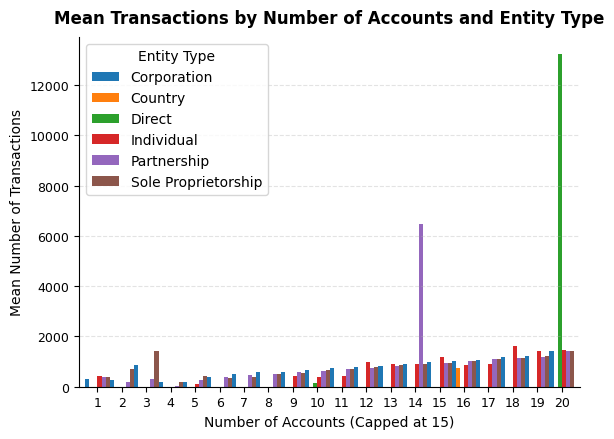

In [17]:
fig, ax = plt.subplots(figsize=(6, 4.5))
pivot = txn_distribution.pivot(index="n_accounts_capped",columns="Entity Type",values="mean_txn")
pivot.plot(kind="bar",ax=ax,width=1)
ax.set_title("Mean Transactions by Number of Accounts and Entity Type",fontsize=12,weight="bold",pad=10)
ax.set_xlabel("Number of Accounts (Capped at 15)", fontsize=10)
ax.set_ylabel("Mean Number of Transactions", fontsize=10)
ax.grid(axis="y",linestyle="--",alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.xticks(rotation=0, fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [2]:
# ---- Reference amount & format-composition fitting (US-to-US, USD only) ----
import numpy as np, pandas as pd, matplotlib.pyplot as plt

REF_TRANS = "../data/aml/LI-Small_Trans.csv"
REF_ACCOUNTS = "../data/aml/LI-Small_accounts.csv"

acc = pd.read_csv(REF_ACCOUNTS, usecols=["Bank Name", "Bank ID"],
                   dtype={"Bank Name": "string", "Bank ID": "int32"})
foreign = acc["Bank Name"].str.match(r"^[A-Za-z ]+ Bank #\d+$")
us_set = set(acc.loc[~foreign, "Bank ID"].unique().tolist())

n, s1, s2 = {}, {}, {}
fmt_all, fmt_laundering = pd.Series(dtype=float), pd.Series(dtype=float)
raw_logs = {"Credit Card": [], "Reinvestment": []}
ge10k = {"Credit Card": [0, 0], "Reinvestment": [0, 0]}  # [count>=10k, total]

cols = ["From Bank", "To Bank", "Amount Received", "Receiving Currency",
        "Payment Format", "Is Laundering"]
for chunk in pd.read_csv(REF_TRANS, usecols=cols, chunksize=1_500_000,
                          dtype={"From Bank": "int32", "To Bank": "int32",
                                 "Amount Received": "float64", "Receiving Currency": "string",
                                 "Payment Format": "string", "Is Laundering": "int8"}):
    chunk = chunk[(chunk["Receiving Currency"] == "US Dollar")
                  & chunk["From Bank"].isin(us_set) & chunk["To Bank"].isin(us_set)
                  & (chunk["Amount Received"] > 0)]
    if chunk.empty:
        continue
    fmt_all = fmt_all.add(chunk["Payment Format"].value_counts(), fill_value=0)
    laund = chunk[chunk["Is Laundering"] == 1]
    if len(laund):
        fmt_laundering = fmt_laundering.add(laund["Payment Format"].value_counts(), fill_value=0)
    for fmt, grp in chunk.groupby("Payment Format", observed=True):
        log_amt = np.log(grp["Amount Received"].to_numpy())
        n[fmt] = n.get(fmt, 0) + len(log_amt)
        s1[fmt] = s1.get(fmt, 0.0) + log_amt.sum()
        s2[fmt] = s2.get(fmt, 0.0) + (log_amt ** 2).sum()
        if fmt in raw_logs and len(raw_logs[fmt]) < 300_000:
            raw_logs[fmt].append(log_amt)
        if fmt in ge10k:
            ge10k[fmt][0] += int((grp["Amount Received"] >= 10000).sum())
            ge10k[fmt][1] += len(grp)

amount_models = {f: {"mean_log": s1[f]/n[f],
                      "std_log": float(np.sqrt(max(s2[f]/n[f] - (s1[f]/n[f])**2, 1e-9)))}
                  for f in n}
fmt_all = fmt_all[fmt_all > fmt_all.sum()*1e-4]; fmt_all /= fmt_all.sum()
fmt_laundering = fmt_laundering.reindex(fmt_all.index).fillna(0.0)
fmt_laundering /= fmt_laundering.sum()
raw_logs = {k: np.concatenate(v) for k, v in raw_logs.items()}
share10k = {f: ge10k[f][0]/ge10k[f][1] for f in ge10k}

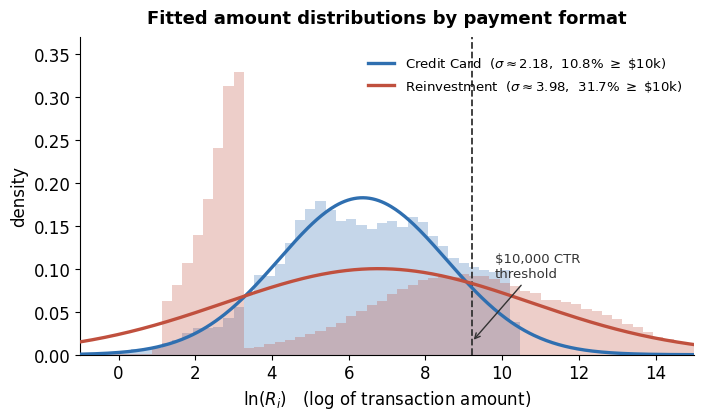

In [4]:
# ---- Figure 1: fitted amount distributions (Credit Card vs Reinvestment) ----
plt.rcParams.update({
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

fig, ax = plt.subplots(figsize=(7.2, 4.6))
colors = {"Credit Card": "#2f6fb0", "Reinvestment": "#c0503e"}
x = np.linspace(-1, 15, 400)

for fmt in ["Credit Card", "Reinvestment"]:
    logs = raw_logs[fmt]
    logs = logs[(logs > -1) & (logs < 15)]
    ax.hist(logs, bins=60, range=(-1, 15), density=True, alpha=0.28,
            color=colors[fmt], edgecolor="none", zorder=1)
    m = amount_models[fmt]
    pdf = (1 / (m["std_log"] * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - m["mean_log"]) / m["std_log"]) ** 2)
    ax.plot(x, pdf, color=colors[fmt], linewidth=2.4, zorder=3,
            label=f"{fmt}  ($\\sigma \\approx {m['std_log']:.2f}$,  {100*share10k[fmt]:.1f}% $\\geq$ \\$10k)")

ax.set_xlim(-1, 15)
ax.set_ylim(0, 0.37)

ctr_line = np.log(10000)
ax.axvline(ctr_line, color="#333333", linestyle="--", linewidth=1.3, zorder=2)
ax.annotate("\\$10,000 CTR\nthreshold",
            xy=(ctr_line, 0.015), xytext=(ctr_line + 0.6, 0.09),
            fontsize=9.5, color="#333333", ha="left",
            arrowprops=dict(arrowstyle="->", color="#333333", lw=1))

ax.set_xlabel(r"$\ln(R_i)$   (log of transaction amount)")
ax.set_ylabel("density")
ax.set_title("Fitted amount distributions by payment format", pad=10)


ax.legend(loc="upper right", fontsize=9.5, frameon=False, bbox_to_anchor=(1.0, 0.98))
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig("figures/fig_amount_distributions.pdf")
fig.savefig("figures/fig_amount_distributions.png", dpi=300)
plt.show()

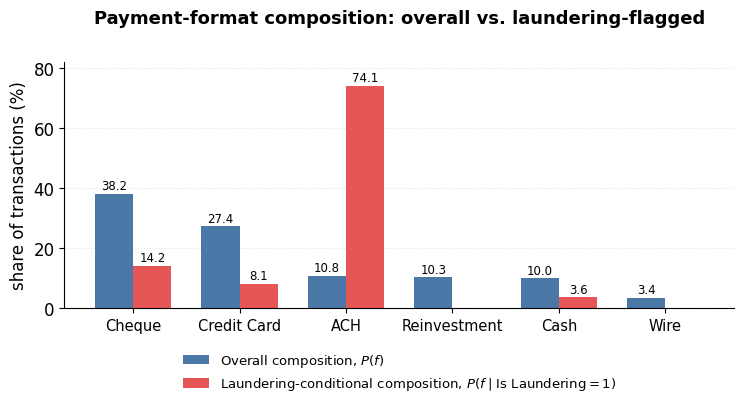

In [6]:
# ---- Figure 2: payment-format composition, overall vs. laundering-conditional ----
formats = sorted(fmt_all.index, key=lambda f: -fmt_all[f])
overall_vals = [100 * fmt_all[f] for f in formats]
laund_vals = [100 * fmt_laundering[f] for f in formats]
x_pos = np.arange(len(formats))
width = 0.36

fig, ax = plt.subplots(figsize=(7.6, 5.1))
b1 = ax.bar(x_pos - width/2, overall_vals, width, label="Overall composition, $P(f)$",
            color="#4c78a8", zorder=2)
b2 = ax.bar(x_pos + width/2, laund_vals, width,
            label="Laundering-conditional composition, $P(f \\mid \\text{Is Laundering}=1)$",
            color="#e45756", zorder=2)

ax.set_xticks(x_pos)
ax.set_xticklabels(formats, rotation=0, ha="center", fontsize=10.5)
ax.set_ylabel("share of transactions (%)")
ax.set_ylim(0, 82)
ax.set_title("Payment-format composition: overall vs. laundering-flagged", pad=28)
ax.grid(axis="y", linestyle=":", alpha=0.35, zorder=0)

for bars in (b1, b2):
    for rect in bars:
        h = rect.get_height()
        if h > 0.5:
            ax.annotate(f"{h:.1f}", (rect.get_x() + rect.get_width()/2, h),
                        textcoords="offset points", xytext=(0, 3), ha="center", fontsize=8.5)

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.13), ncol=1, fontsize=9.5, frameon=False)
fig.tight_layout(rect=[0, 0.06, 1, 0.93])
fig.savefig("figures/fig_format_composition.pdf")
fig.savefig("figures/fig_format_composition.png", dpi=300)
plt.show()